### Wavefront Calibration

Thus far, our examples have made two important assumptions:

- The SLM is perfectly in the Fourier domain without aberration (connected to the imaging domain via an ideal Fourier transform)
- The optical amplitude of the source beam covers the SLM uniformly.

Generally, in practical experiments, both assumptions are **false**.

- Beamline misalignment, defocus, or imperfect optics will cause [optical aberration](https://en.wikipedia.org/wiki/Optical_aberration).
- The source beam will generally be Gaussian, and cannot cover the SLM uniformly without significant loss.

In this example, we will make use of functions and calibrations built into `slmsuite` to:

- Correct for optical aberration, such that phase profiles can be displayed with compensation, and
- Measure the sourced amplitude, such that GS-type optimization algorithms use a better base approximation of the system (see `slmsuite.holography.algorithms`).

#### Initialization

To start, we initialize our system consisting of a camera and an SLM separated by a Fourier transform.

In [1]:
# Header. This is hidden from sphinx with the json metadata:
#   {"nbsphinx":"hidden"}

# ipython configuration (reloads source code automatically and plots inline)
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os, sys
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rc('image', cmap='inferno')


In [2]:
# Try to load physical hardware.
try:
    from slmsuite.hardware.slms.texasinstruments import PLM
    from slmsuite.hardware.cameras.flir import FLIR

    # Load the hardware.
    slm = PLM(
        'p67',
        display_number=2,
        configure_usb=True,
        usb_device_number=1,
        wav_um=0.488,
        settle_time_s=0.05,
        name='PLM',
    )

    cam = FLIR(
        serial="22562470",
        pitch_um=2.74, 
        bitdepth=12,
        name="FLIR Cam"
    )

    # Use the full camera since the uncorrected reflection is off-center
    cam.set_woi(None)   

    # Load the composite CameraSLM.
    from slmsuite.hardware.cameraslms import FourierSLM
    fs = FourierSLM(cam, slm)

    # Load pixel calibration (also called LUT or gamma correction).
    # (Detailed in a later tutorial)
    fs.load_calibration('pixel', 'slm2_pixel_calibration_1-5V.h5')
    fs.pixel_calibration_process(plot=False)

# Fallback to virtual hardware.
except Exception as e:
    print(f"Loading physical hardware failed; loading virtual hardware. Error:\n{str(e)}")
    from slmsuite.hardware.slms.simulated import SimulatedSLM
    from slmsuite.hardware.cameras.simulated import SimulatedCamera

    # Make the SLM and camera.
    slm = SimulatedSLM((1600, 1200), pitch_um=(8,8))
    from slmsuite.holography.toolbox.phase import zernike_sum
    phase_aberration = zernike_sum(
        slm,
        indices=(3, 4, 5, 7, 8),
        weights=(1, -2, 3, 1, 1),
        aperture=None,
        use_mask=False
    )
    slm.set_source_analytic(                        # Program the virtual source.
        phase_offset=phase_aberration,
        sim=True
    )

    # The upstream SLM in our setup tilts the beam onto this one, so we add that tilt to the
    # virtual aberration: as on the hardware, an unblazed SLM then misses the camera center.
    from slmsuite.holography import toolbox
    slm.source["phase_sim"] -= toolbox.phase.blaze(
        slm, toolbox.convert_vector((0.28, -0.01), from_units="freq", to_units="norm", hardware=slm)
    )
    slm.plot_source(sim=True)

    # Wide enough for the Fourier calibration grid, which the tilt moves off center.
    cam = SimulatedCamera(slm, (2560, 1536), pitch_um=(4,4), gain=200)

    # Tie the camera and SLM together with an analytic calibration.
    from slmsuite.hardware.cameraslms import FourierSLM
    fs = FourierSLM(cam, slm)
    M, b = fs.fourier_calibration_build(
        f_eff=80000.,                              # f_eff of 80000 wavelengths or 80 mm with the default 1 um wavelength
        theta=5 * np.pi / 180,
    )
    cam.set_affine(M, b)
    fs.fourier_calibrate_analytic(M, b)

[INF] 17:31:58 PLM Initialized PLM on display 2.
[INF] 17:32:02 FLIR Cam Initialized FLIR.
[INF] 17:32:03 FLIR Cam-PLM Initialized FourierSLM.
[INF] 17:32:03 FLIR Cam-PLM Loaded 'pixel' calibration from 'slm2_pixel_calibration_1-5V.h5'.


Let's make a helper function which we will use to display results. It autoexposes the camera on whatever is currently displayed, so every spot is well exposed.

In [3]:
def plot(title="", cam_limits=.1):

    old_exposure = cam.get_exposure()
    exposure_s = cam.autoexpose(set_fraction=0.5)

    _, axs = plt.subplots(1, 2, figsize=(16,6))
    plt.sca(axs[0]); fs.slm.plot(slm.phase, title="Displayed Phase", cbar=True)
    plt.sca(axs[1]); fs.cam.plot(title=f"Camera Result (exposure {exposure_s:.1e} s)", limits=cam_limits, cbar=True)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

    cam.set_exposure(old_exposure)

#### Without Wavefront Calibration

An uncalibrated SLM will generally not achieve diffraction-limited performance. For instance, some SLMs possess inherent curvature, which must be calibrated for ideal operation. We can take a look at this aberration:

[INF] 17:32:04 FLIR Cam Autoexpose: 5.50e-05 s - 2311/4095


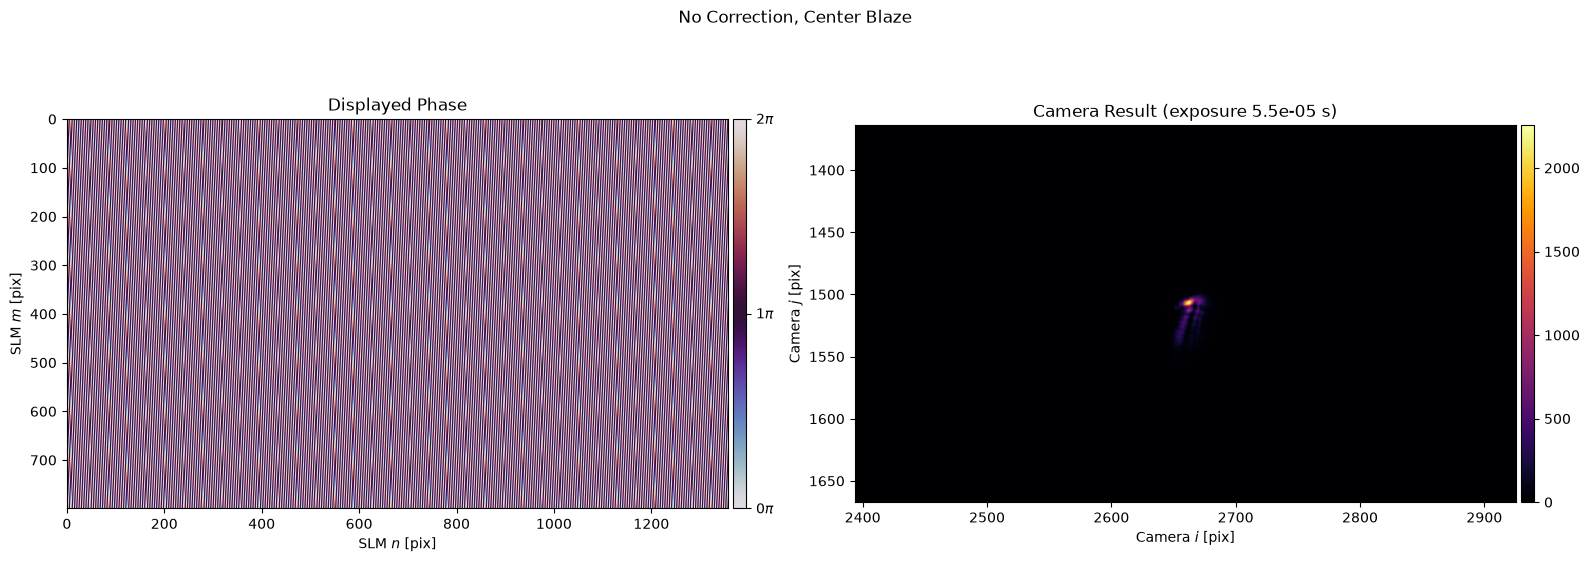

[INF] 17:32:06 FLIR Cam Autoexpose: 5.50e-05 s - 2084/4095


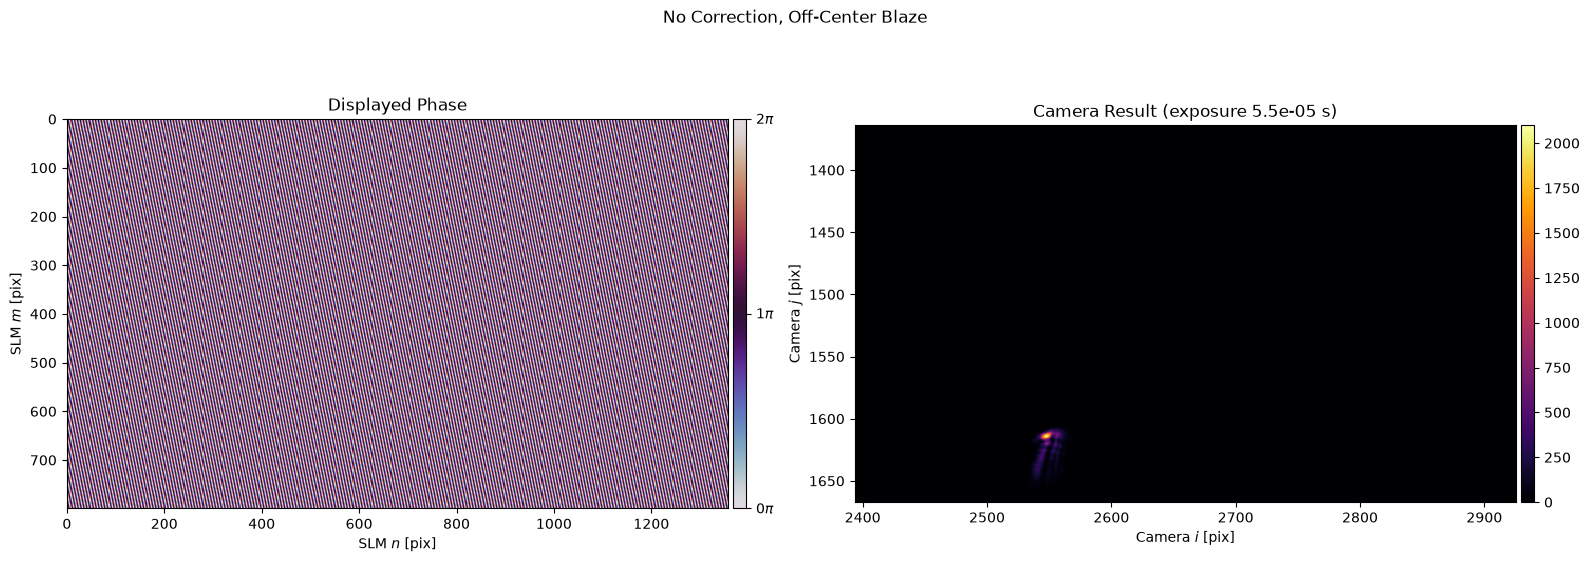

In [4]:
# Our SLM zero order is offset from the camera center, so we'll center it here
from slmsuite.holography import toolbox
from slmsuite.holography.toolbox.phase import blaze

center_blaze = blaze(grid=slm,
                     vector=toolbox.convert_vector((0.28,-0.01), from_units="freq", to_units="norm", hardware=fs))

slm.set_phase(center_blaze, settle=True)
plot(title="No Correction, Center Blaze")

slm.set_phase(center_blaze + blaze(grid=slm, vector=(.002, .002)), settle=True)
plot(title="No Correction, Off-Center Blaze")

#### With Vendor Phase Calibration

Some vendors provide phase calibration data for the wavefront of their SLMs, usually acquired by [Shack-Hartmann](https://en.wikipedia.org/wiki/Shack%E2%80%93Hartmann_wavefront_sensor) wavefront sensing. 
Subclasses implementing a vendor's SDK can also support the `SLM.load_vendor_phase_correction()` function to interpret the file provided by the vendor (`.csv` in the case of Santec).
Unfortunately, we didn't have this information for our SLM so we here leave the example code commented out.

In [5]:
# slm.load_vendor_phase_correction(
#     file_path='Wavefront_correction_Data_221136000005(830nm).csv',  # Update this path to load your calibration
#     smooth=True
# )

Regardless, we can often do better than vendor calibrations due to dependencies related to our specific setup.
The vendor-provided data only corrects for aberration on the SLM, but does not know about other beamline aberrations related to our setup. Additionally, information regarding source amplitude is valuable for holography. Calibrating these values, as aforementioned, is the goal of `FourierSLM.wavefront_calibrate_superpixel()`.

#### Fourier Calibration

The automated wavefront calibration routines which are part of `slmsuite` are conducted through camera feedback. For this to work, we first need to calibrate the camera's Fourier domain (see Experimental Holography). Notice that this method works even with the highly aberrated system point spread function.

[INF] 17:32:07 Fourier Grid Initialized SpotHologram.


Fourier Grid: 100%|██████████| 10/10 [00:00<00:00, 191.28it/s]


[INF] 17:32:09 FLIR Cam Autoexpose: 7.73e-03 s - 2068/4095


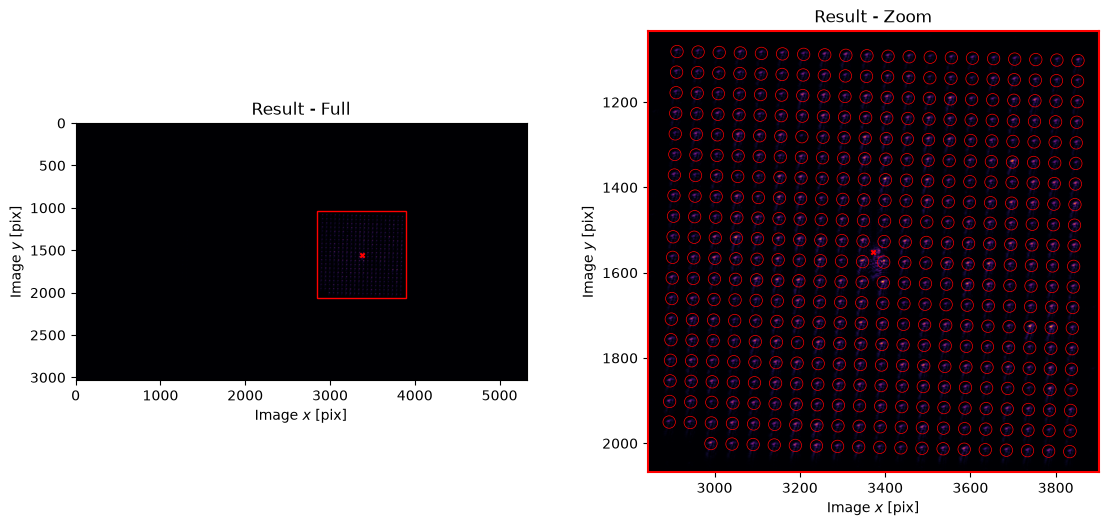

In [6]:
fs.fourier_calibrate(
    array_shape=20,                 # Size of the calibration grid (Nx, Ny) [knm]
    array_pitch=40,                 # Pitch of the calibration grid (x, y) [knm]
    autoexpose=True,                # Set the exposure on the projected grid
    plot=True
);

Now that we're calibrated, we can reduce the window of interest to the camera region that we're actually interested in: the center of the camera.
This isn't strictly necessary, but our camera is huge so here we want to window to speed up the frame rate (and demonstrate some more `slmsuite` functionality).

Since the calibration results are stored in reference to the raw sensor pixel positions (`ij_raw`) instead of the row/column coordinates returned from a windowed camera image (`ij`), the calibration survives the WOI change.

In [7]:
# The resulting warning simply notifies us that the WOI applied is slightly
# shifted from the one we requested due to camera limitations.
cam.set_woi(1024)

[WRN] 17:32:12 FLIR Cam Attempted to set WOI to (2148, 1024, 1004, 1024), but realized (2148, 1024, 1000, 1024).


(2148, 1024, 1000, 1024)

#### Live Viewer

Especially for long calibrations or experiments, 
it is often useful to see what the hardware is doing in realtime.
`.live()` updates a zoomable window with the image or phase pattern every time `get_image` (camera) or `set_phase` (SLM) is called.
When the `[Live]` button is toggled, the camera grabs frames on a loop (useful for alignment).

The default backend using `ipywidgets` updates a window inside the notebook.
If `pyglet` (used for `ScreenMirrored` SLMs) is installed, passing this as a `backend=` will produce a separate window.
Note that `.live()` comes with a slight overhead to render each frame, so should be turned off when the fastest performance is required.

In [8]:
cam.live(backend="pyglet")

HTML(value='', tooltip='Clicked coordinates, saved file paths, and viewer errors.')

In [9]:
slm.live(backend="pyglet")

HTML(value='', tooltip='Clicked coordinates, saved file paths, and viewer errors.')

#### Testing Wavefront Calibration

Now we are ready for wavefront calibration. This is a 
[serial process](https://doi.org/10.1038/nphoton.2010.85) where 'superpixels'
on the SLM of size `superpixel_size`$\times$`superpixel_size` pixels are tested one
after another. We are looking to measure, as mentioned in the introduction, two things:

- A local phase correction factor about each superpixel, to counteract optical aberration, and
- A measurement of the optical amplitude at each superpixel. 

We can measure these by:

- Interfering a given superpixel with some reference superpixel (chosen by default to be at the center of the SLM). A fit to the resulting interference fringes yields a measurement of the phase correction needed to bring the given superpixel into the same Fourier plane as the reference superpixel.
- Integrating the power (amplitude squared) confined in the diffraction order corresponding to the superpixel.

`FourierSLM.wavefront_calibrate_superpixel()` is designed with a testing feature, such that when
the `test_index` keyword is passed, the user is provided with helper plots to make sure
that calibration is working at the superpixel corresponding to `test_index`. Shown below
is the result for the superpixel with index `1`: the 1st step in the wavefront
calibration's sweep. If one looks closely at the phase, small square
superpixels can be seen where power is diffracted into a different order. Note the
titles of the plots which explain the purpose of each step in this process. The final
returned dictionary contains the data that will be gathered from each superpixel on the
SLM.

First, the exposure. Superpixel calibration captures every frame at the camera's current
exposure, so we set it beforehand. The brightest frame the calibration will see is two
neighboring superpixels near the center of the SLM, where the source is brightest, interfering
constructively at the calibration point. We display a stand-in for that frame (a two-superpixel
patch blazed to the calibration point, with the rest of the SLM blazed toward `field_point` as
the calibration does), then autoexpose on the calibration's interference window, so that field
light elsewhere on the camera does not set the exposure.

This also gives us the opportunity to find a clean calibration point (free of noisy reflections, etc.) near the center of the camera and a field_point that moves reflected light from non-superpixel regions of the slm away from the calibration point.

In [10]:
from slmsuite.holography import toolbox

# Calibration parameters, shared by the test and the full calibration below.
calibration_point = (450, 512)             # Where superpixels interfere ["ij"]
field_point = (-0.1, 0.22)                  # Where the rest of the field is blazed ["freq"]
superpixel_size = 75

# Stand-in for the brightest calibration frame: two neighboring superpixels at the center
# of the SLM, in phase and blazed to the calibration point, with the field blazed away.
field_blaze = toolbox.convert_vector(field_point, from_units="freq", to_units="kxy", hardware=slm)
brightest_frame = blaze(grid=slm, vector=field_blaze)
toolbox.imprint(
    brightest_frame,
    window=[slm.shape[1] // 2, 2 * superpixel_size, slm.shape[0] // 2, superpixel_size],
    function=blaze,
    grid=slm,
    vector=fs.ijcam_to_kxyslm(calibration_point),
    centered=True
)
slm.set_phase(brightest_frame, settle=True)

# Autoexpose within the interference window around the calibration point.
w, h = fs.wavefront_calibration_superpixel_window(superpixel_size).ravel()
calibration_exposure_s = cam.autoexpose(
    set_fraction=0.8,
    window=[int(calibration_point[0] - w // 2), int(w), int(calibration_point[1] - h // 2), int(h)]
)

[INF] 17:32:13 FLIR Cam Autoexpose: 7.73e-03 s - 2147/4095


With the exposure set, we can run the test. We're also going to activate a special mode (`plot=3`) to generate a .gif sweeping across the interference condition.

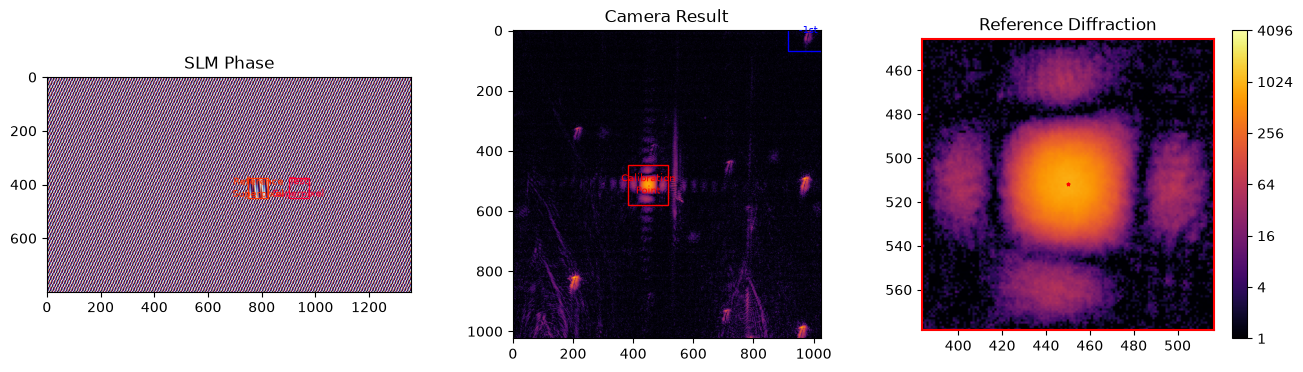

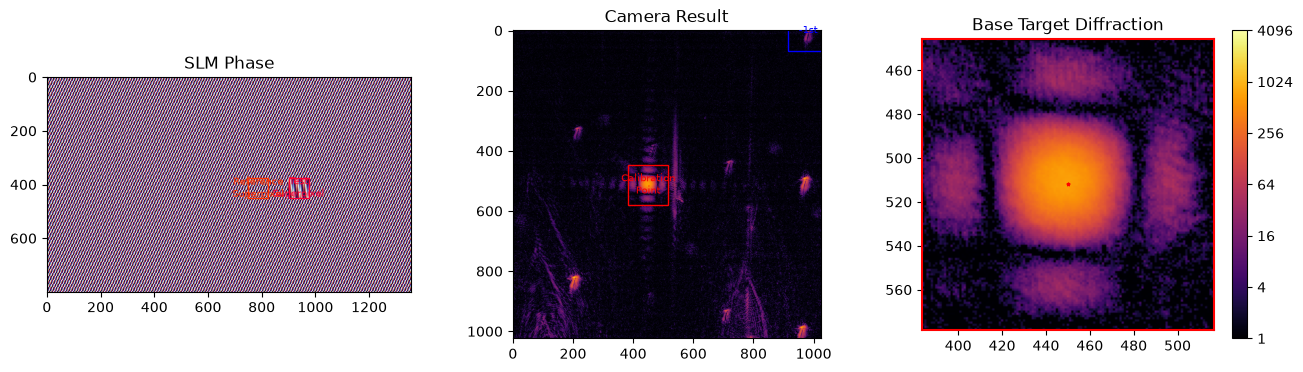

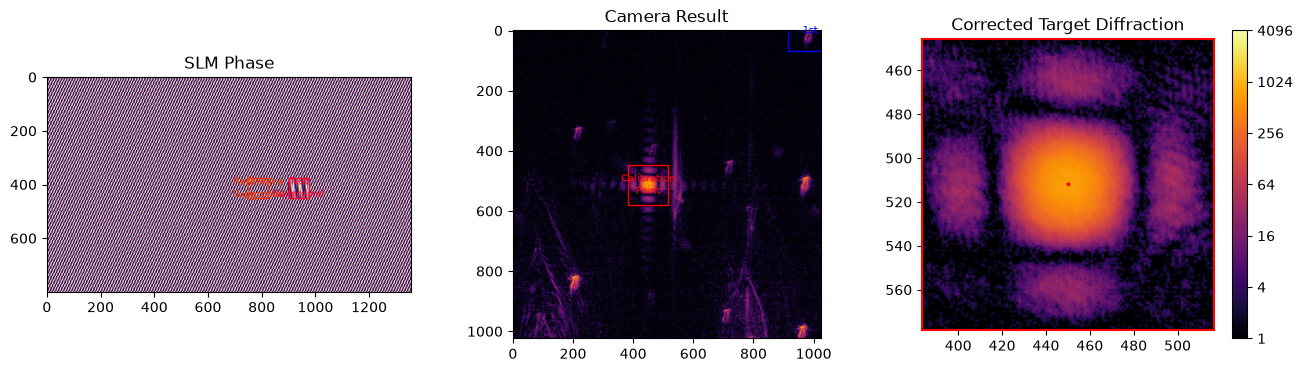

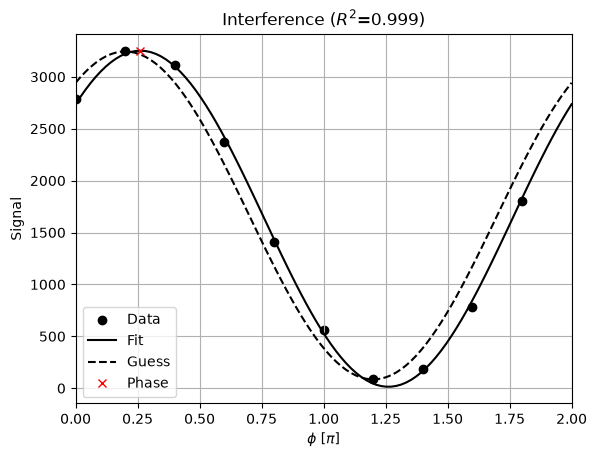

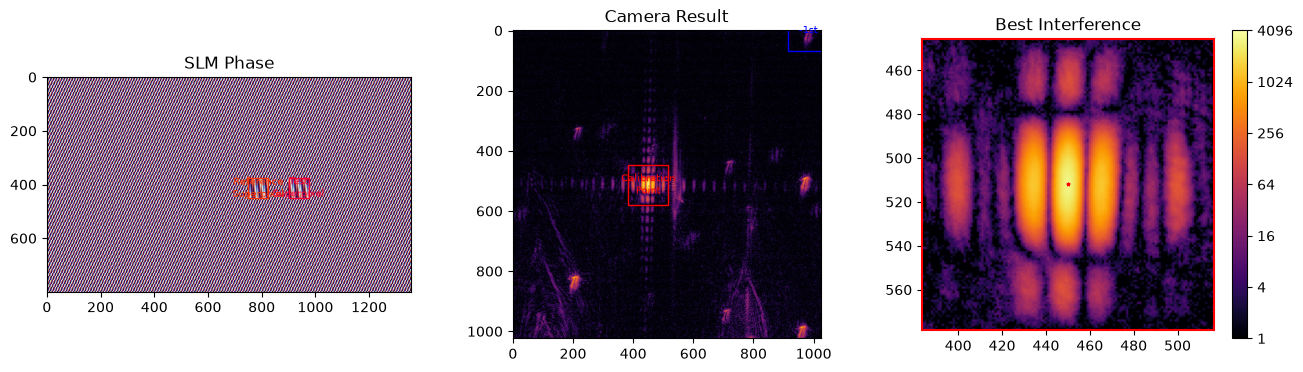

In [11]:
movie = fs.wavefront_calibrate_superpixel(
    calibration_points=calibration_point,
    field_point=field_point,
    field_point_units="freq",
    superpixel_size=superpixel_size,
    corrected_amplitude=True,
    test_index=1,                       # Testing mode
    phase_steps=10,                     # Step through phase for the .gif
    plot=3                              # Special mode to generate a phase .gif
)

from slmsuite.holography.analysis.files import save_image

save_image("wavefront.gif", movie, loop=0)

We use markdown to display the .gif we just made:

![Phase Movie](wavefront.gif)



The diffracted spot resulting from these rectangular superpixels matches their Fourier transform: the amplitude of a rectangular [sinc](https://en.wikipedia.org/wiki/Sinc_function) function.

Note that this function returns the result of calibration on a given superpixel, where `'power'`, `'normalization'`, and `'background'` deal with parameters relevant to amplitude calibration, and other parameters—especially `'phase'`, `'kx'`, and `'ky'`—are relevant for phase calibration.

Testing allows the user to hone parameters for more ideal calibration, specifically:

- `calibration_points`, the point in the camera's `"ij"` basis where interference takes place.
    - As the plural implies, `slmsuite` can simultaneously calibrate at many points, but for this tutorial we just feed one point.
    - The `calibration_points` should be far from sources of noise, especially the ordered diffraction peaks of the field which contain the vast majority of the optical power in the system.
    - Wavefront calibration works best in a region around each of the `calibration_points`. The extent of this region depends on the parameters of the optical system and the nature of the aberrations.
- `field_point`, the point in the camera's `"ij"` basis where the field (power not in a superpixel) is deflected towards.
    - This is useful because it reduces the power in the 0th order. This should be chosen such that higher diffraction orders from the field are far away from the `calibration_points`.
- Camera exposure.
    - Calibration does not change the exposure, so the camera must not be overexposed during the calibration process. Above, we autoexposed on a stand-in for the brightest frame; if fits look clipped or noisy, adjust `set_fraction`. Trying different `test_index` superpixels (with higher or lower power) is a good check.
- `superpixel_size`, the size in SLM pixels of each superpixel.
    - In general, this should be chosen to be as small as reasonable within SNR and time constraints.
    - Ideally, it would also be a divisor of both the width and height of the SLM, so there are no cropped superpixels.
- `test_index`, which iteration to examine as a test (described above).
    - Based on how the calibration is scheduled, small indices will generally yield
      interference superpixels that are close to the reference superpixel, which usually
      produces the brightest results if the SLM source is centered. This also provides
      an opportunity to check for overexposure.

#### Wavefront Calibration

With calibration working on this test case, we proceed to do this process over the full SLM. Removing the `test_index` keyword disables testing mode and begins a long serial process of testing each superpixel. `tqdm` bars monitor progress for user feedback (though these may not be visible in the final notebook).

In [12]:
cam.set_exposure(calibration_exposure_s)            # The exposure found before testing.

fs.wavefront_calibrate_superpixel(
    calibration_points=calibration_point,
    field_point=field_point,
    field_point_units="freq",
    superpixel_size=superpixel_size,
    phase_steps=6,                      # Fit a phase sweep at each superpixel.
);

C:\Users\holodyne\Documents\GitHub\slmsuite\slmsuite\hardware\cameraslms\_wavefront_superpixel.py:602: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = optimize.curve_fit(cos, phases, intensities, p0=guess)
calibration: 100%|██████████| 208/208 [05:13<00:00,  1.51s/it]  


We should save the data immediately after this measurement.

In [13]:
fs.save_calibration("wavefront_superpixel");

[INF] 17:37:34 FLIR Cam-PLM Saved 'wavefront_superpixel' calibration to 'c:\Users\holodyne\Documents\GitHub\slmsuite-examples\examples\FLIR Cam-PLM-wavefront_superpixel-calibration_00002.h5'.


#### Processing Wavefront Calibration

The raw data from wavefront calibration is stored and saved in a compressed form, where a few floating numbers are recorded for each superpixel. To use this data, we still need to process the information on a per-pixel basis, rather than per-superpixel. This is done by `FourierSLM.wavefront_calibration_superpixel_process()`. There are a few options (among others) available to the user for honing calibration processing.

- `r2_threshold` sets the threshold for which bad fits are ignored. Notice below that there is significant clipping in the domain of the SLM. Within the clipped region, the fits are good, but outside it's noise. The threshold `r2_threshold` can be adjusted to omit or include superpixels at the user's preference (boundary marked as red lines in the below plots). There are a few adaptive features to guess what the phase would look like in below-threshold superpixels.
- `smooth` adds blurring to the final result to smooth out the discretization caused by the superpixel approach. This will yield better results in practice as it avoids discontinuities between superpixels.

[WRN] 17:37:34 FLIR Cam-PLM remove_background is enabled and a noise floor was detected; removing this background (1.0% of the average normalization).


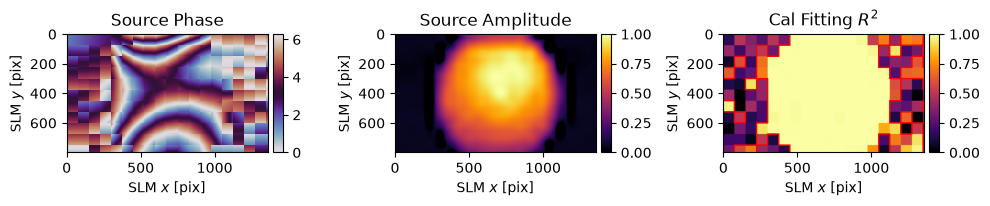

In [14]:
# Without smoothing
fs.wavefront_calibration_superpixel_process(r2_threshold=.5, smooth=False, plot=True);

[WRN] 17:37:35 FLIR Cam-PLM remove_background is enabled and a noise floor was detected; removing this background (1.0% of the average normalization).


smooth: 100%|██████████| 16/16 [00:00<00:00, 25.66it/s]


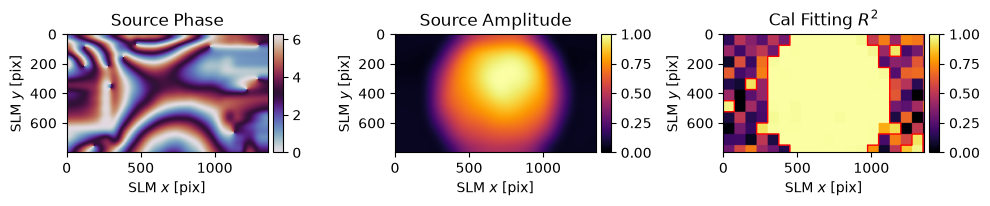

In [15]:
# With smoothing
fs.wavefront_calibration_superpixel_process(r2_threshold=.8, smooth=True, plot=True, remove_background=True);

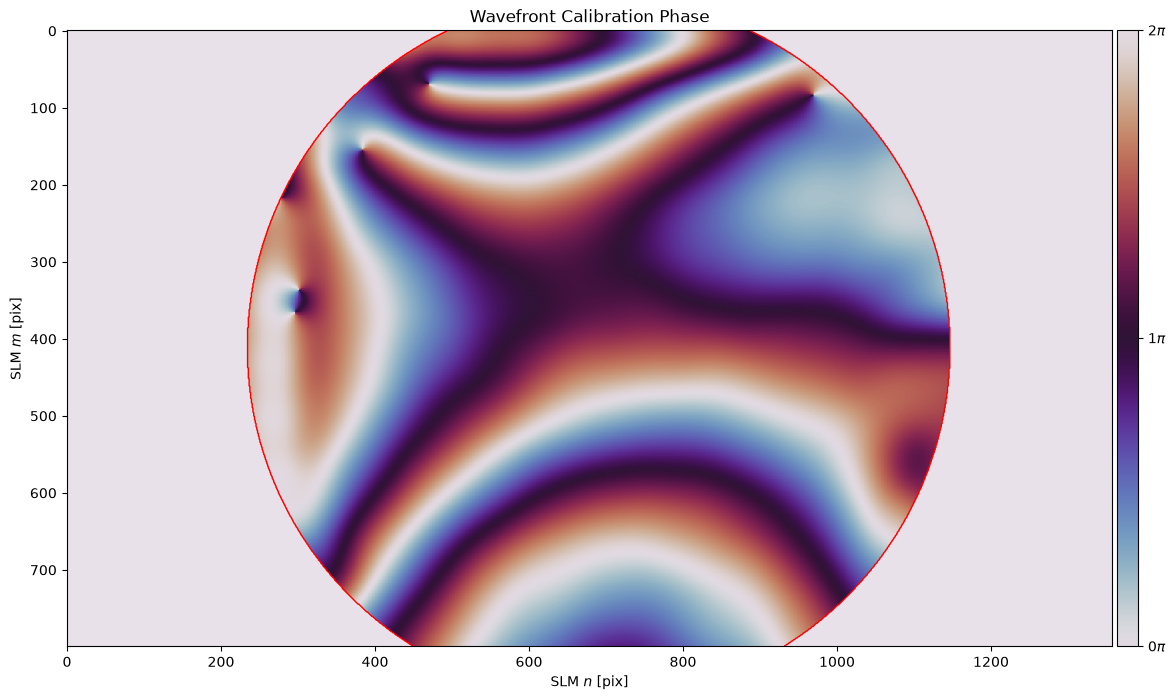

In [16]:
# Make a plot for the thumbnail.
# We'll talk more about apertures in a later tutorial, for now we apply one
# to limit the results to the region where our source is large.
slm.fit_aperture()

slm.plot(slm.source["phase"] * slm.aperture_mask, title="Wavefront Calibration Phase");

Now let's revisit our plots from earlier. Instead of having a distorted spot, our power is far more concentrated!

[INF] 17:37:38 FLIR Cam Autoexpose: 2.90e-05 s - 4095/4095


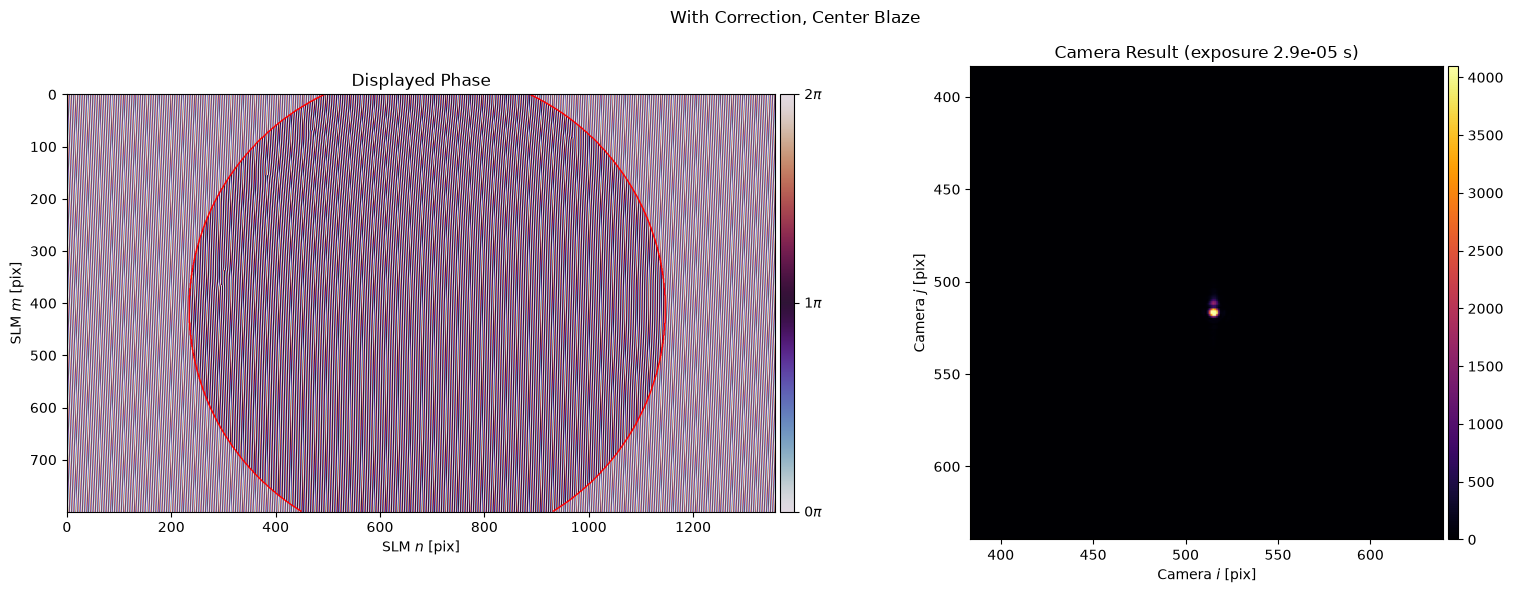

[INF] 17:37:40 FLIR Cam Autoexpose: 2.90e-05 s - 4095/4095


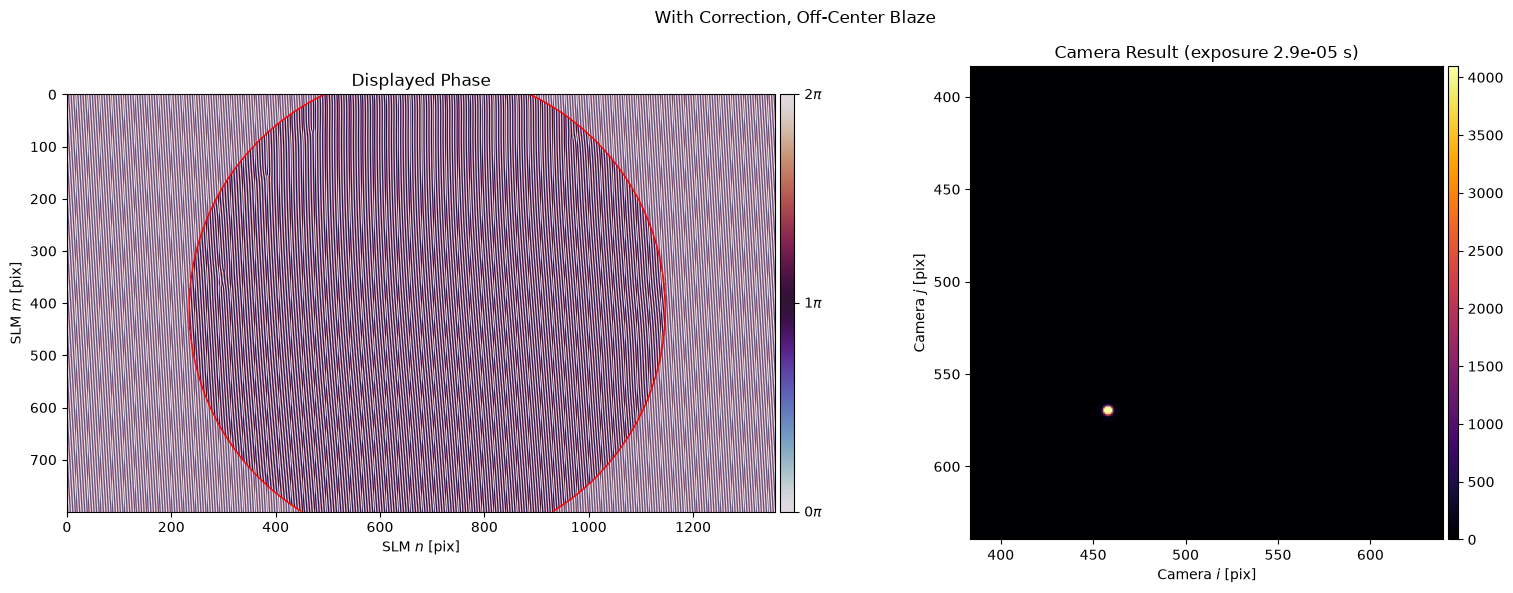

In [17]:
slm.set_phase(center_blaze, settle=True)
plot(title="With Correction, Center Blaze", cam_limits=0.25)

slm.set_phase(center_blaze + blaze(grid=slm, vector=(.001, .001)), settle=True)
plot(title="With Correction, Off-Center Blaze", cam_limits=0.25)

#### Scoring the Result on Simulated Hardware

If you ran this example with virtual hardware, we programmed the aberration ourselves into
`slm.source["phase_sim"]`. The recovered correction `slm.source["phase"]` should be the
negative of that aberration, up to a few things the calibration cannot or need not see:

- a constant piston, which has no physical effect,
- a net tilt, which only moves the spot (`remove_blaze=True` deliberately strips it from the
  correction, and re-running Fourier calibration below absorbs the shift), and
- anything outside the beam, where superpixels see no light and their fits mean nothing.

So we weight the comparison by the simulated source power, remove piston and tilt, and compare
*wrapped* phase, since a residual of $2\pi$ is not an error.

In [18]:
from slmsuite.misc.xp import as_numpy

def wavefront_error(phase, power):
    """Power-weighted RMS of a wrapped wavefront, ignoring piston and tilt."""
    field = np.exp(1j * phase)

    # Remove the mean tilt, measured with the wrap-aware phase gradient.
    tilt_x = np.angle(np.sum(power[:, 1:] * field[:, 1:] * np.conj(field[:, :-1])))
    tilt_y = np.angle(np.sum(power[1:, :] * field[1:, :] * np.conj(field[:-1, :])))
    y_grid, x_grid = np.indices(phase.shape)
    field = field * np.exp(-1j * (tilt_x * x_grid + tilt_y * y_grid))

    # Remove the mean piston.
    field = field * np.exp(-1j * np.angle(np.sum(power * field)))

    residual = np.angle(field)
    return np.sqrt(np.sum(power * np.square(residual))), residual

if "phase_sim" not in slm.source:
    print("Physical hardware has no known aberration to score against.")
else:
    aberration = as_numpy(slm.source["phase_sim"])              # The aberration we programmed.
    recovered = as_numpy(slm.source["phase"])                   # The correction the calibration measured.
    power = np.square(as_numpy(slm.source["amplitude_sim"]))    # Weight by where the light actually is.
    power = power / np.sum(power)

    before_rms, _ = wavefront_error(aberration, power)                          # No correction applied.
    after_rms, residual = wavefront_error(aberration + recovered, power)       # The correction should cancel the aberration.

    # Strehl ratios use the Marechal approximation exp(-rms^2), valid for small errors.
    print("wavefront error before correction: {:.3f} rad (Strehl ~ {:.3f})".format(before_rms, np.exp(-before_rms**2)))
    print("wavefront error after correction : {:.3f} rad (Strehl ~ {:.3f})".format(after_rms, np.exp(-after_rms**2)))

    plt.figure(figsize=(8, 5))
    plt.imshow(np.where(power > np.max(power) * np.exp(-2), residual, np.nan), cmap="RdBu_r", vmin=-np.pi, vmax=np.pi)
    plt.colorbar(label="residual phase [rad]")
    plt.title("What the calibration missed (inside the $1/e^2$ beam)")
    plt.show()

Physical hardware has no known aberration to score against.


#### Re-Running Fourier Calibration

Wavefront calibration will usually shift spot positions slightly due to net blaze in the calibration.
This is mitigated to some extent with the `remove_blaze=True` parameter in `wavefront_calibration_superpixel_process`,
but isn't perfect due to higher order aberration terms with variable blaze over the aperture.

Thus, we suggest re-running Fourier calibration after calibrating the wavefront. To this end, `slmsuite` will warn the user
that the Fourier calibration is 'stale' if a newer wavefront calibration is detected during coordinate transformations.

In [19]:
fs.ijcam_to_kxyslm([500, 500])

array([[ 0.01293292],
       [-0.00062537]])

Let's save the calibration's shift vector for comparison later.

In [20]:
b_old = fs.calibrations["fourier"]["b"]

Performing Fourier calibration after the wavefront is calibrated also leads to a significantly cleaner spot
array for fitting, compared to distorted pre-wavefront-calibration spots which could be mis-fit.

[INF] 17:37:40 Fourier Grid #2 Initialized SpotHologram.


Fourier Grid: 100%|██████████| 10/10 [00:00<00:00, 1272.97it/s]


[INF] 17:37:43 FLIR Cam Autoexpose: 8.67e-04 s - 2095/4095


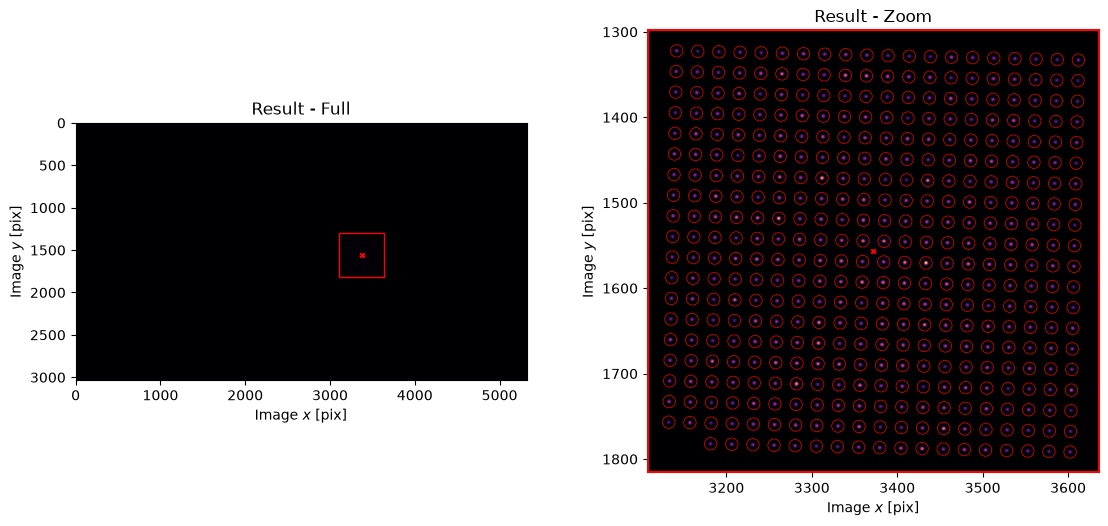

In [21]:
cam.set_woi(None)
fs.fourier_calibrate(
    array_shape=20,                 # Size of the calibration grid (Nx, Ny) [knm]
    array_pitch=20,                 # Pitch of the calibration grid (x, y) [knm]
    autoexpose=True,                # Set the exposure on the projected grid
    plot=True
);

Indeed, our Fourier calibration shifts by a few pixels after wavefront correction:

In [22]:
b_new = fs.calibrations["fourier"]["b"]
b_new - b_old

array([[-0.38139755],
       [ 6.51624773]])

#### Where Next

Superpixel calibration measures one phase mask to correct in a neighborhood of a single
calibration point. Aberration in a real optical train varies across the field of view,
and a single additive mask cannot correct all of it at once. 

The [Multipoint Calibration](multipoint_calibration.ipynb) example calibrates at many points
simultaneously, and introduces the Zernike-space alternative that bakes the correction into
the hologram itself.

In [23]:
slm.close()
cam.close()